# 01 - Train an unconditional flow-matching model

We now train a small MLP to transport Gaussian noise into the three-cluster data
distribution. The model never receives a class label.

**Learning goals**

1. Implement independent conditional flow matching (I-CFM).
2. Sample the learned ODE with a deterministic solver.
3. Explain sliced Wasserstein distance through one-dimensional projections.
4. Diagnose distribution quality with plots and metrics, not loss alone.
5. Save one checkpoint used by the later steering notebooks.


In [1]:
import sys
from pathlib import Path

NOTES_DIR = Path.cwd()
if not (NOTES_DIR / "toy_notes.py").exists():
    NOTES_DIR = Path("notebooks/toy_data")
sys.path.insert(0, str(NOTES_DIR.resolve()))

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from toy_notes import *

SEED = 2026
set_seed(SEED)
device = choose_device()
print(environment_summary(device))


{'torch': '2.9.1+cu128', 'device': 'cuda', 'gpu': 'NVIDIA RTX A6000', 'cuda': '12.8'}


## 1. The complete training objective

For each minibatch:

1. sample independent `x_noise` and `x_data`;
2. sample `t` uniformly from `[0,1]`;
3. form `x_t = t*x_data + (1-t)*x_noise`;
4. regress `v_theta(t,x_t)` onto `x_data - x_noise` with mean-squared error.

This is I-CFM. It is not optimal-transport CFM because we do not solve an
optimal coupling between noise and data samples.


In [2]:
# The helper implements the four lines above and caches the checkpoint so every
# later notebook can also run independently.
model, losses, trained_now = load_or_train_model(device=device)
print("trained in this run:", trained_now)
print("checkpoint:", CHECKPOINT_PATH.relative_to(NOTES_DIR))
print("parameters:", sum(p.numel() for p in model.parameters()))


trained in this run: False
checkpoint: artifacts/toy_flow_model.pt
parameters: 34050


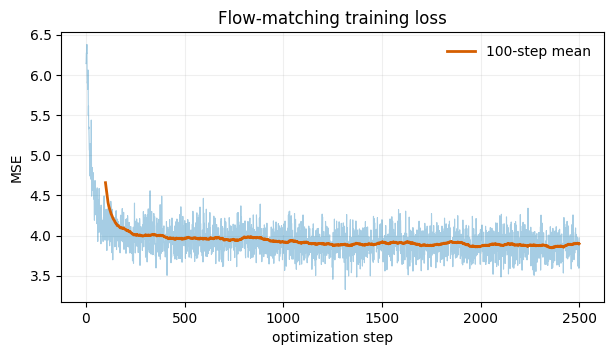

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(losses, color="#0072B2", alpha=0.35, lw=0.8)
if len(losses) >= 100:
    window = 100
    smooth = np.convolve(losses, np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window - 1, len(losses)), smooth, color="#D55E00", lw=2, label="100-step mean")
    ax.legend(frameon=False)
ax.set(xlabel="optimization step", ylabel="MSE", title="Flow-matching training loss")
ax.grid(alpha=0.2)
plt.show()


## 2. Generate samples by solving an ODE

Once an initial noise batch is fixed, the ODE sampler is deterministic:

$$\frac{dx}{dt}=v_\theta(t,x), \qquad x(0)=x_{noise}.$$

We use Heun's method here. Notebook `02` compares it with Euler and RK4.


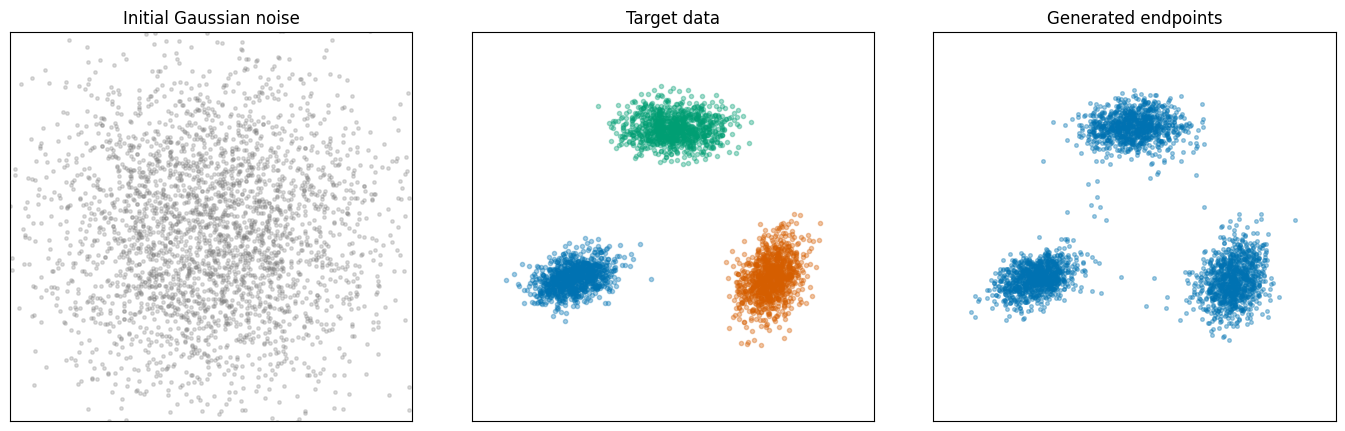

sampling time: 0.154 s


In [4]:
set_seed(SEED + 10)
x0_eval = sample_base(3000, device=device)
trajectory, sample_seconds = timed_sample(base_velocity(model), x0_eval, steps=80, method="heun")
generated = trajectory[-1].to(device)
target, target_labels = sample_labeled_mixture(3000, device=device)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
axes[0].scatter(x0_eval[:, 0].cpu(), x0_eval[:, 1].cpu(), s=6, alpha=0.25, color="#777777")
axes[0].set_title("Initial Gaussian noise")
plot_labeled_points(target, target_labels, ax=axes[1], title="Target data", alpha=0.35)
axes[2].scatter(generated[:, 0].cpu(), generated[:, 1].cpu(), s=7, alpha=0.35, color="#0072B2")
axes[2].set_title("Generated endpoints")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.2, 4.5)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
print(f"sampling time: {sample_seconds:.3f} s")


In [5]:
stats = estimate_gaussian_stats(target, target_labels)
predicted = predict_classes(generated, stats)
generated_balance = torch.bincount(predicted, minlength=len(CLASS_NAMES)).float()
generated_balance /= generated_balance.sum()

diagnostics = pd.DataFrame({
    "diagnostic": [
        "sliced Wasserstein to full target",
        "generated class balance max error",
        "smallest generated mode fraction",
        "all samples finite",
    ],
    "value": [
        sliced_wasserstein(generated, target),
        float(torch.max(torch.abs(generated_balance - 1 / len(CLASS_NAMES))).cpu()),
        float(generated_balance.min().cpu()),
        bool(torch.isfinite(generated).all()),
    ],
})
display(diagnostics)
print("generated class balance:", generated_balance.cpu().numpy().round(3))

# These are broad smoke checks, not a proof of distributional equality.
generation_checks = pd.DataFrame({
    "broad sanity check": ["finite endpoints", "all three modes represented", "no severe mode imbalance"],
    "passed": [
        bool(torch.isfinite(generated).all()),
        bool((generated_balance > 0.15).all()),
        bool(torch.max(torch.abs(generated_balance - 1 / len(CLASS_NAMES))) < 0.10),
    ],
})
display(generation_checks)
print("broad visual/metric sanity verdict:", "PASS" if generation_checks["passed"].all() else "CHECK OUTPUT")


,diagnostic,value
0,sliced Wasserstein to full target,0.048917
1,generated class balance max error,0.001
2,smallest generated mode fraction,0.332333
3,all samples finite,True


generated class balance: [0.333 0.334 0.332]


,broad sanity check,passed
0,finite endpoints,True
1,all three modes represented,True
2,no severe mode imbalance,True


broad visual/metric sanity verdict: PASS


### How sliced Wasserstein distance compares two clouds

A class rate or a mean checks only one property. **Sliced Wasserstein distance
(SWD)** compares the shapes of two complete point clouds:

1. choose a direction and project both clouds onto that one-dimensional line;
2. sort the projected values and compare corresponding positions;
3. repeat for many directions and aggregate the squared gaps.

The figure below illustrates the same computation used by `sliced_wasserstein`.
Lower is better, and zero means that every illustrated projection agrees.
SWD is still only one summary: mode coverage and within-mode spread remain
useful separate checks.


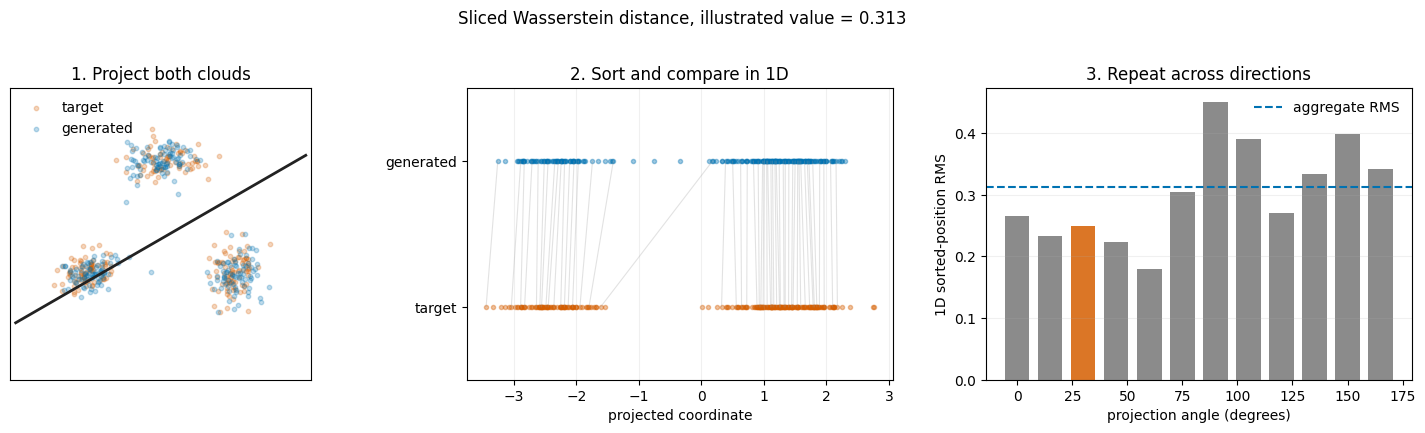

In [6]:
# Use a small, fixed subset so every stage of the SWD calculation is visible.
visual_count = 240
visual_generated = generated[:visual_count]
visual_target = target[:visual_count]
slice_angles = torch.arange(12, device=device) * np.pi / 12
slice_directions = torch.stack([torch.cos(slice_angles), torch.sin(slice_angles)], dim=1)
generated_projections = torch.sort(visual_generated @ slice_directions.T, dim=0).values
target_projections = torch.sort(visual_target @ slice_directions.T, dim=0).values
projection_gaps = torch.sqrt(torch.mean((generated_projections - target_projections).square(), dim=0))
illustrated_swd = torch.sqrt(torch.mean((generated_projections - target_projections).square()))
selected_slice = 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].scatter(
    visual_target[:, 0].cpu(), visual_target[:, 1].cpu(),
    s=10, alpha=0.25, color="#D55E00", label="target",
)
axes[0].scatter(
    visual_generated[:, 0].cpu(), visual_generated[:, 1].cpu(),
    s=10, alpha=0.25, color="#0072B2", label="generated",
)
line_coordinate = torch.linspace(-5, 5, 100, device=device)
slice_line = line_coordinate[:, None] * slice_directions[selected_slice]
axes[0].plot(slice_line[:, 0].cpu(), slice_line[:, 1].cpu(), color="#222222", lw=2)
axes[0].set(title="1. Project both clouds", aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.2, 4.5))
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].legend(frameon=False, loc="upper left")

generated_1d = generated_projections[:, selected_slice].cpu()
target_1d = target_projections[:, selected_slice].cpu()
for index in range(0, visual_count, 5):
    axes[1].plot(
        [target_1d[index], generated_1d[index]], [0.25, 0.75],
        color="#999999", alpha=0.28, lw=0.8,
    )
axes[1].scatter(target_1d, torch.full_like(target_1d, 0.25), s=9, alpha=0.38, color="#D55E00")
axes[1].scatter(generated_1d, torch.full_like(generated_1d, 0.75), s=9, alpha=0.38, color="#0072B2")
axes[1].set(
    title="2. Sort and compare in 1D", xlabel="projected coordinate",
    yticks=[0.25, 0.75], yticklabels=["target", "generated"], ylim=(0, 1),
)
axes[1].grid(alpha=0.18, axis="x")

angle_degrees = slice_angles.cpu().numpy() * 180 / np.pi
bar_colors = ["#D55E00" if index == selected_slice else "#777777" for index in range(len(slice_angles))]
axes[2].bar(angle_degrees, projection_gaps.cpu(), width=11, color=bar_colors, alpha=0.85)
axes[2].axhline(float(illustrated_swd.cpu()), color="#0072B2", ls="--", label="aggregate RMS")
axes[2].set(
    title="3. Repeat across directions", xlabel="projection angle (degrees)",
    ylabel="1D sorted-position RMS",
)
axes[2].legend(frameon=False)
axes[2].grid(alpha=0.18, axis="y")

fig.suptitle(f"Sliced Wasserstein distance, illustrated value = {float(illustrated_swd.cpu()):.3f}", y=1.02)
plt.tight_layout()
plt.show()


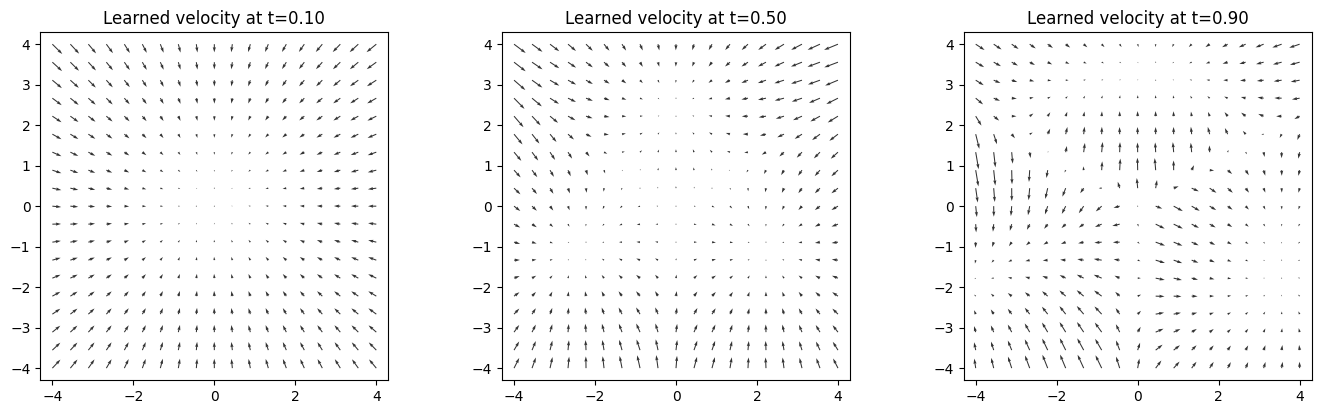

In [7]:
# A vector field is easier to understand when it is drawn.
grid_1d = torch.linspace(-4, 4, 19, device=device)
gx, gy = torch.meshgrid(grid_1d, grid_1d, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, t_value in zip(axes, [0.10, 0.50, 0.90]):
    t = torch.full((grid.shape[0],), t_value, device=device)
    with torch.no_grad():
        vectors = model(t, grid)
    ax.quiver(
        grid[:, 0].cpu(), grid[:, 1].cpu(), vectors[:, 0].cpu(), vectors[:, 1].cpu(),
        angles="xy", scale_units="xy", scale=18, width=0.003, color="#333333",
    )
    ax.set_title(f"Learned velocity at t={t_value:.2f}")
    ax.set_aspect("equal")
    ax.set_xlim(-4.3, 4.3)
    ax.set_ylim(-4.3, 4.3)
plt.tight_layout()
plt.show()


## 3. A learned flow map to eight Gaussian modes

The three-class model is kept for the steering notebooks because its labels are
easy to discuss. To make the transport map itself more visible, we train a
second unconditional model on eight narrow Gaussian components arranged on a
ring. This is still learned I-CFM: no destination center is used by the sampler.

We color each particle by the component nearest to its **final** endpoint, then
trace the same particle backward through stored time slices. The colors are for
reading the map after sampling; the model never receives them.


,setting,value
0,training steps,3000
1,training seed,2106
2,base std,1.8
3,component std,0.2
4,hidden width,128
5,cache used,True
6,load/train seconds,0.004832


eight-Gaussian checkpoint SHA-256: 3450806ec8275ea26ae874aca5f46ae422e196d7795d989f4556338ab598dc6e


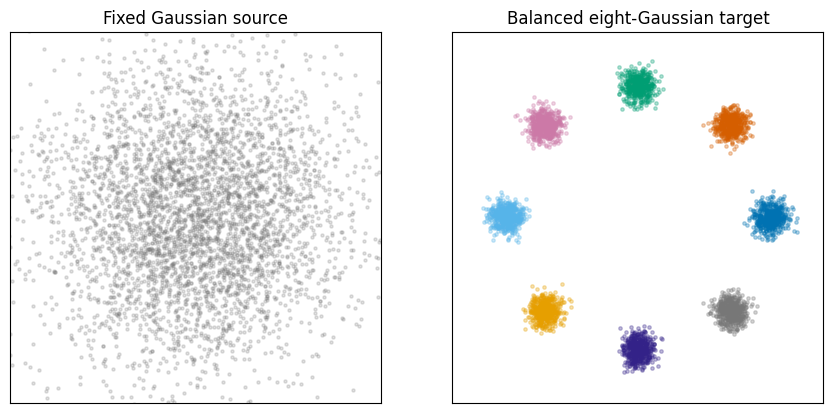

eight-mode sampling seconds: 0.048


In [8]:
import os
import time

main_checkpoint_digest_before = file_sha256(CHECKPOINT_PATH)
ring_train_started = time.perf_counter()
ring_model, ring_losses, ring_trained_now = load_or_train_eight_gaussian_model(device=device)
ring_train_seconds = time.perf_counter() - ring_train_started
assert file_sha256(CHECKPOINT_PATH) == main_checkpoint_digest_before

ring_payload = torch.load(EIGHT_GAUSSIAN_CHECKPOINT_PATH, map_location="cpu", weights_only=False)
ring_config = pd.DataFrame({
    "setting": ["training steps", "training seed", "base std", "component std", "hidden width", "cache used", "load/train seconds"],
    "value": [
        ring_payload["training_steps"], ring_payload["training_seed"], ring_payload["base_std"],
        ring_payload["component_std"], ring_payload["hidden_dim"], not ring_trained_now, ring_train_seconds,
    ],
})
display(ring_config)
print("eight-Gaussian checkpoint SHA-256:", file_sha256(EIGHT_GAUSSIAN_CHECKPOINT_PATH))

set_seed(SEED + 81)
ring_x0 = sample_base(4096, device=device)
ring_target_labels = torch.arange(8, device=device).repeat_interleave(512)
ring_target, ring_target_labels = sample_eight_gaussians(
    ring_target_labels.numel(), device=device, labels=ring_target_labels
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
axes[0].scatter(ring_x0[:, 0].cpu(), ring_x0[:, 1].cpu(), s=5, alpha=0.22, color="#777777")
axes[0].set_title("Fixed Gaussian source")
for component in range(8):
    points = ring_target[ring_target_labels == component].cpu()
    axes[1].scatter(points[:, 0], points[:, 1], s=6, alpha=0.30, color=EIGHT_GAUSSIAN_COLORS[component])
axes[1].set_title("Balanced eight-Gaussian target")
for ax in axes:
    ax.set(aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

ring_sample_started = time.perf_counter()
ring_path = integrate_ode(base_velocity(ring_model), ring_x0, steps=80, method="heun")
ring_sample_seconds = time.perf_counter() - ring_sample_started
ring_generated = ring_path[-1].to(device)
ring_centers = EIGHT_GAUSSIAN_CENTERS.to(device)
ring_assignments = torch.cdist(ring_generated, ring_centers).argmin(dim=1)
print(f"eight-mode sampling seconds: {ring_sample_seconds:.3f}")


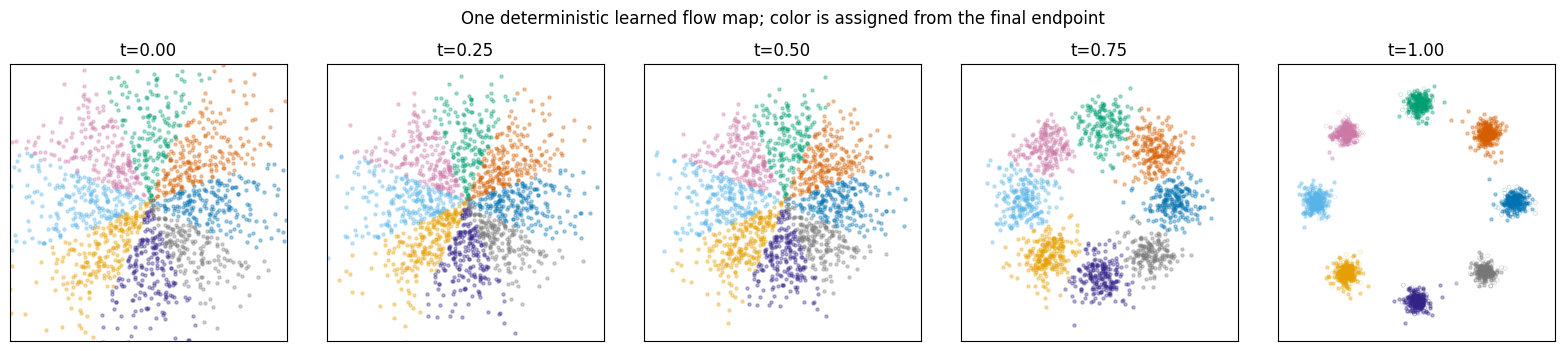

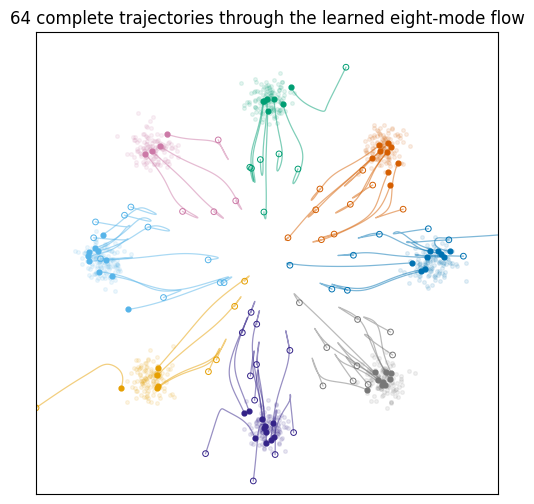

In [9]:
snapshot_steps = [0, 20, 40, 60, 80]
plot_indexes = torch.linspace(0, ring_path.shape[1] - 1, 1600).long()
plot_assignments = ring_assignments[plot_indexes.to(device)].cpu()
fig, axes = plt.subplots(1, len(snapshot_steps), figsize=(16, 3.4))
for ax, step_index in zip(axes, snapshot_steps):
    for component in range(8):
        mask = plot_assignments == component
        points = ring_path[step_index][plot_indexes][mask]
        ax.scatter(
            points[:, 0], points[:, 1], s=5, alpha=0.33,
            color=EIGHT_GAUSSIAN_COLORS[component],
        )
        if step_index == 80:
            reference = ring_target[ring_target_labels == component][:90].detach().cpu()
            ax.scatter(
                reference[:, 0], reference[:, 1], s=8, facecolors="none", alpha=0.28,
                edgecolors=EIGHT_GAUSSIAN_COLORS[component], linewidths=0.5,
            )
    ax.set_title(f"t={step_index / 80:.2f}")
    ax.set_aspect("equal")
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("One deterministic learned flow map; color is assigned from the final endpoint", y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 6.0))
for component in range(8):
    reference = ring_target[ring_target_labels == component][:120].detach().cpu()
    ax.scatter(reference[:, 0], reference[:, 1], s=7, alpha=0.10, color=EIGHT_GAUSSIAN_COLORS[component])
indexes = torch.linspace(0, ring_path.shape[1] - 1, 64).long()
for index in indexes:
    index = int(index)
    component = int(ring_assignments[index].cpu())
    ax.plot(
        ring_path[:, index, 0], ring_path[:, index, 1],
        color=EIGHT_GAUSSIAN_COLORS[component], alpha=0.50, lw=0.9,
    )
    ax.scatter(ring_path[0, index, 0], ring_path[0, index, 1], s=17, facecolors="none", edgecolors=EIGHT_GAUSSIAN_COLORS[component], linewidths=0.7)
    ax.scatter(ring_path[-1, index, 0], ring_path[-1, index, 1], s=12, color=EIGHT_GAUSSIAN_COLORS[component])
ax.set(title="64 complete trajectories through the learned eight-mode flow", aspect="equal", xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))
ax.set_xticks([])
ax.set_yticks([])
plt.show()


In [10]:
generated_counts = torch.bincount(ring_assignments, minlength=8).float()
generated_fractions = generated_counts / generated_counts.sum()
target_assignments = torch.cdist(ring_target, ring_centers).argmin(dim=1)
target_counts = torch.bincount(target_assignments, minlength=8).float()
target_fractions = target_counts / target_counts.sum()

uniform_fractions = torch.full_like(generated_fractions, 1 / 8)
occupancy_tv = float((0.5 * torch.abs(generated_fractions - uniform_fractions).sum()).cpu())
base_swd = sliced_wasserstein(ring_x0, ring_target)
ring_swd = sliced_wasserstein(ring_generated, ring_target)
ring_swd_ratio = ring_swd / base_swd
covered_modes = int((generated_fractions >= 0.05).sum().cpu())

mode_rows = []
for component in range(8):
    generated_mode = ring_generated[ring_assignments == component]
    target_mode = ring_target[ring_target_labels == component]
    target_mean = target_mode.mean(dim=0)
    target_rms = torch.sqrt((target_mode - target_mean).square().sum(dim=1).mean())
    centroid_error = torch.linalg.norm(generated_mode.mean(dim=0) - target_mean) / target_rms.clamp_min(1e-8)
    generated_trace = torch.var(generated_mode, dim=0, unbiased=False).sum()
    target_trace = torch.var(target_mode, dim=0, unbiased=False).sum()
    mode_rows.append({
        "mode": component,
        "generated share": float(generated_fractions[component].cpu()),
        "target share": float(target_fractions[component].cpu()),
        "normalized centroid error": float(centroid_error.cpu()),
        "within-mode trace ratio": float((generated_trace / target_trace).cpu()),
    })
mode_table = pd.DataFrame(mode_rows)
display(mode_table.round(3))

ring_diagnostics = pd.DataFrame({
    "diagnostic": [
        "modes with at least 5% generated mass",
        "occupancy total variation from uniform",
        "source-to-target SWD",
        "generated-to-target SWD",
        "generated/source SWD ratio",
        "mean normalized centroid error",
        "median within-mode trace ratio",
        "all endpoints finite",
    ],
    "value": [
        covered_modes,
        occupancy_tv,
        base_swd,
        ring_swd,
        ring_swd_ratio,
        mode_table["normalized centroid error"].mean(),
        mode_table["within-mode trace ratio"].median(),
        bool(torch.isfinite(ring_generated).all()),
    ],
})
display(ring_diagnostics.round(4))
print("generated occupancy:", generated_fractions.cpu().numpy().round(3))
print("target occupancy:   ", target_fractions.cpu().numpy().round(3))

ring_checks = pd.DataFrame({
    "release check": [
        "all samples finite",
        "all eight mode shares at least 0.05",
        "occupancy total variation at most 0.15",
        "generated SWD at most half source SWD",
        "mean normalized centroid error at most 1.5",
        "median trace ratio in [0.5, 2.5]",
        "every trace ratio at least 0.25",
        "checkpoint metadata matches requested geometry",
    ],
    "passed": [
        bool(torch.isfinite(ring_generated).all()),
        covered_modes == 8,
        occupancy_tv <= 0.15,
        ring_swd_ratio <= 0.50,
        mode_table["normalized centroid error"].mean() <= 1.5,
        0.5 <= mode_table["within-mode trace ratio"].median() <= 2.5,
        mode_table["within-mode trace ratio"].min() >= 0.25,
        ring_payload["training_steps"] == int(os.environ.get("TOY_NOTES_EIGHT_STEPS", "3000"))
        and ring_payload["component_std"] == EIGHT_GAUSSIAN_STD,
    ],
})
display(ring_checks)
print("eight-mode map release verdict:", "PASS" if ring_checks["passed"].all() else "CHECK OUTPUT")


,mode,generated share,target share,normalized centroid error,within-mode trace ratio
0,0,0.128,0.125,0.274,1.046
1,1,0.129,0.125,0.140,1.378
2,2,0.120,0.125,0.225,1.208
3,3,0.124,0.125,0.107,0.938
4,4,0.132,0.125,0.267,1.255
5,5,0.128,0.125,0.110,1.025
6,6,0.125,0.125,0.034,1.014
7,7,0.114,0.125,0.212,0.853


,diagnostic,value
0,modes with at least 5% generated mass,8
1,occupancy total variation from uniform,0.017578
2,source-to-target SWD,0.779792
3,generated-to-target SWD,0.107507
4,generated/source SWD ratio,0.137866
5,mean normalized centroid error,0.171227
6,median within-mode trace ratio,1.035701
7,all endpoints finite,True


generated occupancy: [0.128 0.129 0.12  0.124 0.132 0.128 0.125 0.114]
target occupancy:    [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


,release check,passed
0,all samples finite,True
1,all eight mode shares at least 0.05,True
2,occupancy total variation at most 0.15,True
3,generated SWD at most half source SWD,True
4,mean normalized centroid error at most 1.5,True
5,"median trace ratio in [0.5, 2.5]",True
6,every trace ratio at least 0.25,True
7,checkpoint metadata matches requested geometry,True


eight-mode map release verdict: PASS


The snapshot figure shows **where the learned ODE sends regions of the initial
Gaussian**, while the diagnostics check mode coverage and occupancy. Passing
these broad checks does not prove that every local density is exact; the SWD and
within-component spread still matter.


## Checkpoint

Before continuing, verify that:

- the loss is finite and decreases;
- generated points cover all three modes;
- the endpoint plot resembles the target distribution;
- the eight-mode map passes broad coverage and occupancy checks;
- both `artifacts/toy_flow_model.pt` and
  `artifacts/eight_gaussian_flow_model.pt` exist.

**Questions**

1. Why can a low minibatch MSE coexist with visibly poor samples?
2. What information about class identity did the unconditional model receive?
3. At which time does the vector field mostly choose coarse destination modes?
